Milan Chavarria, Trevor Henderson
dataset: https://www.kaggle.com/datasets/wenruliu/adult-income-dataset

In [ ]:
# Import libraries for data handling, visualization, and machine learning
# Load the dataset and preview the first 5 rows

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,       # Split data into train/test sets
    cross_val_score         # Cross-validation for robust evaluation
)
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
df=pd.read_csv('adult.csv')
print(df.head(5))

   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0             0   

   hours-per-week native-country incom

In [ ]:
# Clean data by removing missing values and dropping unneeded columns
# Convert text categories to numbers so the model can process them
# most import part of this code is making sure feature engineering is done
# bad inputs = bad outputs

df = pd.read_csv('adult.csv')

df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
df.drop(columns=['fnlwgt', 'education'], inplace=True)

cat_cols = ['workclass', 'marital-status', 'occupation', 'relationship',
            'race', 'gender', 'native-country', 'income']

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

print("Shape:", df.shape)
print(df.dtypes)
print(f"\nFirst 3 rows:\n{df.head(3)}")

Shape: (45222, 13)
age                int64
workclass          int64
educational-num    int64
marital-status     int64
occupation         int64
relationship       int64
race               int64
gender             int64
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country     int64
income             int64
dtype: object

First 3 rows:
   age  workclass  educational-num  marital-status  occupation  relationship  \
0   25          2                7               4           6             3   
1   38          2                9               2           4             0   
2   28          1               12               2          10             0   

   race  gender  capital-gain  capital-loss  hours-per-week  native-country  \
0     2       1             0             0              40              38   
1     4       1             0             0              50              38   
2     4       1             0             0              40          

In [ ]:
# Print the numeric mapping for each encoded category column
# this is more a quality of life piece of code to make sure our feature engineering and label ecoding worked

for col, encoder in encoders.items():
    mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
    print(f"{col}: {mapping}")

workclass: {'Federal-gov': np.int64(0), 'Local-gov': np.int64(1), 'Private': np.int64(2), 'Self-emp-inc': np.int64(3), 'Self-emp-not-inc': np.int64(4), 'State-gov': np.int64(5), 'Without-pay': np.int64(6)}
marital-status: {'Divorced': np.int64(0), 'Married-AF-spouse': np.int64(1), 'Married-civ-spouse': np.int64(2), 'Married-spouse-absent': np.int64(3), 'Never-married': np.int64(4), 'Separated': np.int64(5), 'Widowed': np.int64(6)}
occupation: {'Adm-clerical': np.int64(0), 'Armed-Forces': np.int64(1), 'Craft-repair': np.int64(2), 'Exec-managerial': np.int64(3), 'Farming-fishing': np.int64(4), 'Handlers-cleaners': np.int64(5), 'Machine-op-inspct': np.int64(6), 'Other-service': np.int64(7), 'Priv-house-serv': np.int64(8), 'Prof-specialty': np.int64(9), 'Protective-serv': np.int64(10), 'Sales': np.int64(11), 'Tech-support': np.int64(12), 'Transport-moving': np.int64(13)}
relationship: {'Husband': np.int64(0), 'Not-in-family': np.int64(1), 'Other-relative': np.int64(2), 'Own-child': np.int6

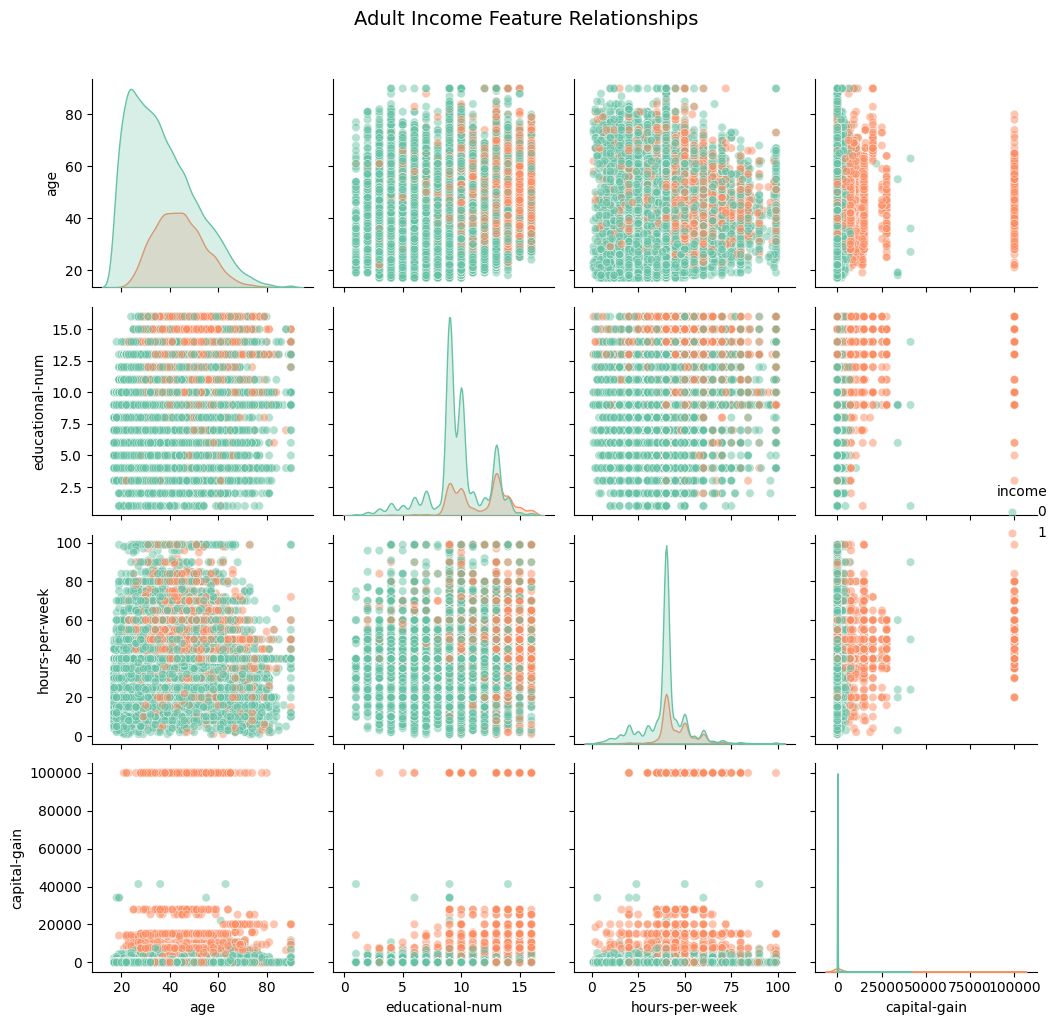

In [ ]:
# Visualize relationships between key features, colored by income class
# this grid of graphs gives a great representation of how different features affect income group

plot_features = ['age', 'educational-num', 'hours-per-week', 'capital-gain', 'income']

sns.pairplot(
    df[plot_features],
    hue='income',
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 'edgecolor': 'w'}
)
plt.suptitle('Adult Income Feature Relationships', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_586/1831675146.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


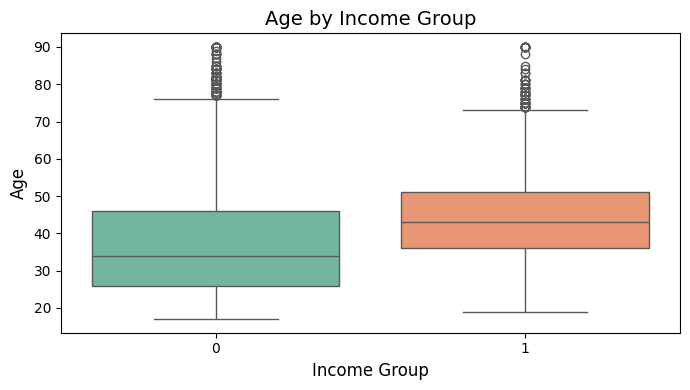

In [ ]:
# Boxplot showing age distribution across income groups
# this gives a good representation of the differences in means in different age groups
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df,
    x='income',
    y='age',
    palette='Set2'
)
plt.xlabel('Income Group', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.title('Age by Income Group', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Separate features (X) from the target label (y) and split into train/test sets
# Scale all features to the same range so distance calculations are fair

print(df.select_dtypes(include='object').columns.tolist())

X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

[]
Training samples: 36177
Testing samples:  9045


Accuracy (K=7): 82.83%

              precision    recall  f1-score   support

       <=50K       0.87      0.91      0.89      6803
        >50K       0.68      0.59      0.63      2242

    accuracy                           0.83      9045
   macro avg       0.77      0.75      0.76      9045
weighted avg       0.82      0.83      0.82      9045



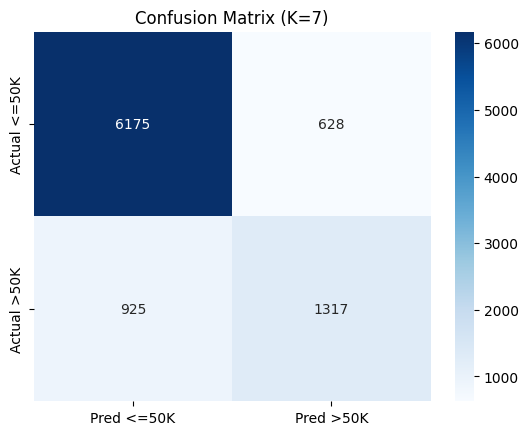

In [ ]:
# Train a KNN model with K=7 and evaluate accuracy on the test set
# Plot a confusion matrix to see where predictions were correct or wrong

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print(f"Accuracy (K=7): {accuracy_score(y_test, y_pred):.2%}\n")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred <=50K', 'Pred >50K'],
            yticklabels=['Actual <=50K', 'Actual >50K'])
plt.title('Confusion Matrix (K=7)')
plt.show()

In [ ]:
# Test K values 1–20 using cross-validation to find the most accurate K
# it is important in this type of machine learning to do optimization of k values for best accuracy
# higher accuracy means better model

k_range  = range(1, 21)
cv_means, cv_stds = [], []

for k in k_range:
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=k),
                             X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    print(f"K={k:2d}  CV Accuracy={scores.mean():.2%}  (±{scores.std():.2%})")

cv_means = np.array(cv_means)
cv_stds  = np.array(cv_stds)
k_list   = list(k_range)
best_k   = k_list[np.argmax(cv_means)]
print(f"\nBest K = {best_k}  |  Best CV Accuracy = {cv_means.max():.2%}")

k_range  = range(1, 21)
cv_means, cv_stds = [], []

for k in k_range:
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=k),
                             X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    print(f"K={k:2d}  CV Accuracy={scores.mean():.2%}  (±{scores.std():.2%})")

cv_means = np.array(cv_means)
cv_stds  = np.array(cv_stds)
k_list   = list(k_range)
best_k   = k_list[np.argmax(cv_means)]
print(f"\nBest K = {best_k}  |  Best CV Accuracy = {cv_means.max():.2%}")

K= 1  CV Accuracy=80.29%  (±0.67%)
K= 2  CV Accuracy=81.94%  (±0.49%)
K= 3  CV Accuracy=82.23%  (±0.83%)
K= 4  CV Accuracy=82.96%  (±0.62%)
K= 5  CV Accuracy=82.94%  (±0.59%)
K= 6  CV Accuracy=83.33%  (±0.45%)
K= 7  CV Accuracy=83.51%  (±0.44%)
K= 8  CV Accuracy=83.60%  (±0.55%)
K= 9  CV Accuracy=83.69%  (±0.44%)
K=10  CV Accuracy=83.72%  (±0.48%)
K=11  CV Accuracy=83.79%  (±0.46%)
K=12  CV Accuracy=83.87%  (±0.42%)
K=13  CV Accuracy=83.88%  (±0.36%)
K=14  CV Accuracy=83.91%  (±0.48%)
K=15  CV Accuracy=83.86%  (±0.49%)
K=16  CV Accuracy=83.93%  (±0.44%)
K=17  CV Accuracy=83.90%  (±0.54%)
K=18  CV Accuracy=83.90%  (±0.39%)
K=19  CV Accuracy=83.90%  (±0.43%)
K=20  CV Accuracy=83.87%  (±0.39%)

Best K = 16  |  Best CV Accuracy = 83.93%


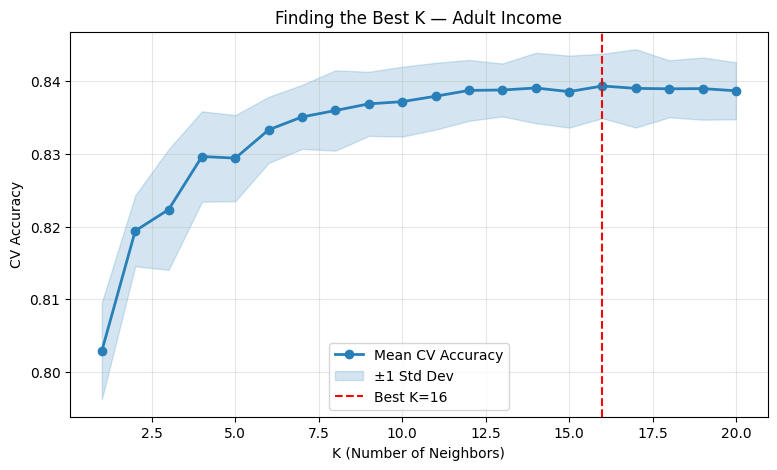

In [ ]:
# Plot CV accuracy for each K value to visually identify the best choice
# visual representation to show management or leadership on how you came to a conclusion

plt.figure(figsize=(9, 5))
plt.plot(k_list, cv_means, marker='o', color='#2980b9', linewidth=2, label='Mean CV Accuracy')
plt.fill_between(k_list, cv_means - cv_stds, cv_means + cv_stds,
                 alpha=0.2, color='#2980b9', label='±1 Std Dev')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('CV Accuracy')
plt.title('Finding the Best K — Adult Income')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Final Accuracy (K=16): 83.74%

              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      6803
        >50K       0.72      0.56      0.63      2242

    accuracy                           0.84      9045
   macro avg       0.79      0.74      0.76      9045
weighted avg       0.83      0.84      0.83      9045



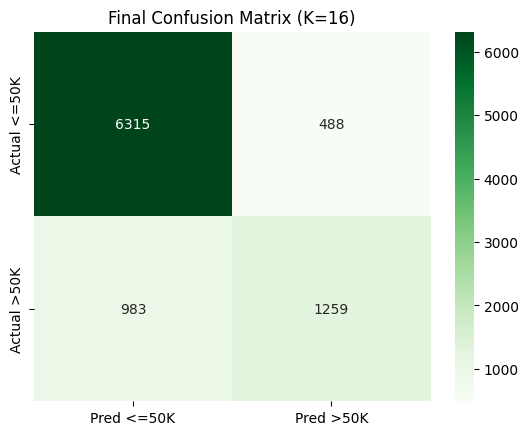

In [ ]:
# Retrain the model using the best K and evaluate final performance
# Plot the final confusion matrix with the optimized model

final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)
y_pred_final = final_model.predict(X_test_scaled)

print(f"Final Accuracy (K={best_k}): {accuracy_score(y_test, y_pred_final):.2%}\n")
print(classification_report(y_test, y_pred_final, target_names=['<=50K', '>50K']))

cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred <=50K', 'Pred >50K'],
            yticklabels=['Actual <=50K', 'Actual >50K'])
plt.title(f'Final Confusion Matrix (K={best_k})')
plt.show()

In [ ]:
# Define three hypothetical people and scale their data to match training format
# Predict each person's income class and display confidence percentages

new_people = pd.DataFrame({
    'age':             [25,    42,    58],
    'workclass':       [2,     2,     5],
    'educational-num': [7,     13,    14],
    'marital-status':  [4,     2,     2],
    'occupation':      [6,     9,     3],
    'relationship':    [3,     0,     0],
    'race':            [2,     4,     4],
    'gender':          [1,     1,     1],
    'capital-gain':    [0,     5000,  15000],
    'capital-loss':    [0,     0,     0],
    'hours-per-week':  [40,    55,    50],
    'native-country':  [38,    38,    38],
})

print("New people measurements:")
print(new_people.to_string(index=False))
print()

new_scaled    = scaler.transform(new_people)
predictions   = final_model.predict(new_scaled)
probabilities = final_model.predict_proba(new_scaled)

class_labels = final_model.classes_

for i in range(len(new_people)):
    print(f"Person #{i+1}:")
    print(f"   Predicted income: {'<=50K' if predictions[i] == 0 else '>50K'}")
    print(f"   Confidence breakdown:")
    for cls_int, prob in zip(class_labels, probabilities[i]):
        label   = '<=50K' if cls_int == 0 else '>50K'
        bar_len = int(prob * 25)
        bar     = '█' * bar_len + '░' * (25 - bar_len)
        print(f"      {label:6s} {bar} {prob:6.1%}")
    print()

New people measurements:
 age  workclass  educational-num  marital-status  occupation  relationship  race  gender  capital-gain  capital-loss  hours-per-week  native-country
  25          2                7               4           6             3     2       1             0             0              40              38
  42          2               13               2           9             0     4       1          5000             0              55              38
  58          5               14               2           3             0     4       1         15000             0              50              38

Person #1:
   Predicted income: <=50K
   Confidence breakdown:
      <=50K  ███████████████████████░░  93.8%
      >50K   █░░░░░░░░░░░░░░░░░░░░░░░░   6.2%

Person #2:
   Predicted income: >50K
   Confidence breakdown:
      <=50K  ███░░░░░░░░░░░░░░░░░░░░░░  12.5%
      >50K   █████████████████████░░░░  87.5%

Person #3:
   Predicted income: >50K
   Confidence breakdown:
     

KNN predicts a person's income by finding the most similar people in the dataset and taking a majority vote on their income label. It compares things like age, education level, and hours worked per week to measure how similar two people are. The more neighbors that earn above $50K, the more likely the new person gets that same prediction. We tested different K values to find the one that gave us the best accuracy on unseen data.

KNN helps managers make better decisions by using data instead of guesswork. It can look at someone's age, education, and work hours and predict whether they are likely to earn above or below $50K. The model also shows how confident it is in each prediction, so managers know when to trust it and when to look closer. This takes some of the uncertainty out of decisions around hiring and compensation.